In [12]:
from qiskit import QuantumCircuit
from qiskit_ibm_provider import IBMProvider
from qiskit import Aer, transpile
from qiskit.quantum_info import DensityMatrix, Operator

# Save account credentials.
# IBMProvider.save_account(token=MY_API_TOKEN)

# Load previously saved account credentials.
provider = IBMProvider()

# Construct a noisy simulator backend from an IBMQ backend
# This simulator backend will be automatically configured
# using the device configuration and noise model 

# provider = IBMProvider()
# provider = IBMProvider(instance="ibm-q-ornl/ornl/csc500")

# Select a backend.
backend = Aer.get_backend('aer_simulator')
# backend = provider.get_backend('simulator_mps')
#backend = provider.get_backend('ibmq_qasm_simulator')
#Display current supported backends
print(provider.backends())

[<IBMBackend('ibmq_qasm_simulator')>, <IBMBackend('ibm_algiers')>, <IBMBackend('ibm_osaka')>, <IBMBackend('simulator_mps')>, <IBMBackend('simulator_stabilizer')>, <IBMBackend('simulator_statevector')>, <IBMBackend('ibm_cusco')>, <IBMBackend('ibm_torino')>, <IBMBackend('ibm_kyoto')>, <IBMBackend('ibm_cairo')>, <IBMBackend('ibm_hanoi')>, <IBMBackend('simulator_extended_stabilizer')>, <IBMBackend('ibm_sherbrooke')>, <IBMBackend('ibm_brisbane')>, <IBMBackend('ibm_nazca')>]


In [13]:
%matplotlib inline
# Importing standard Qiskit libraries
from qiskit import *
from qiskit.compiler import transpile, assemble
from qiskit.tools.jupyter import *
from qiskit.visualization import *
#
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from scipy import linalg as la
from qiskit_textbook.tools import array_to_latex
from math import pi

In [14]:
### Physical parameters (atomic units) ###
# J = 1.0    # Exchange coupling
# B = 0.5    # Transverse magnetic field
#dt = 0.01  # Time-discretization unit

# J_ij = 1/2
N= 4
J =  1/(N-1) #1/N
t = 0.00005
psi = J*t

In [20]:
### Build a circuit ###
#circ = QuantumCircuit(2, 2)  # 2 quantum & 2 classical registers
# def ising(circ,q0,q1,c0,c1,dt):
    # alpha = 2* dt* J_ij
    # circ.rxx(alpha, 0, 1)
    # circ.ryy(alpha, 0, 1)
    # circ.rzz(alpha, 0, 1)
    # circ.cx(0, 1)        # Exchange-coupling time propagation (1)
    # circ.rz(alpha, 1)  #                                    (2)
    # circ.cx(0, 1)        #                                    (3)
    # circ.rx(-2*dt*B, 0)  # Transverse-field propagation of spin 0
    # circ.rx(-2*dt*B, 1)  # Transverse-field propagation of spin 0
    # circ.cx(0, 1)        # Exchange-coupling time propagation (1)
    # circ.rz(-2*dt*J, 1)  #                                    (2)
    # circ.cx(0, 1)        #                                    (3)
def heisenberg(qc,qr,cr):
    for i in range(N//2):
        qc.x(i) 
        qc.barrier()
    for i in range(N-1):
        #sigma_x sigma_x term
        qc.ry(pi/2, qr[i])
        qc.ry(pi/2, qr[i+1])
        qc.cx(qr[i],qr[i+1])
        qc.rz(2*psi, qr[i+1])
        qc.cx(qr[i],qr[i+1])
        qc.ry(-pi/2, qr[i+1])
        qc.ry(-pi/2, qr[i])
        qc.barrier()
    
    for i in range(N-1):      
        #sigma_y sigma_y term
        qc.rx(pi/2, qr[i])
        qc.rx(pi/2, qr[i+1])
        qc.cx(qr[i],qr[i+1])
        qc.rz(2*psi, qr[i+1])
        qc.cx(qr[i],qr[i+1])
        qc.rx(-pi/2, qr[i+1])
        qc.rx(-pi/2, qr[i])
        qc.barrier()
        
    for i in range(N-1):            
        #sigma_z sigma_z term
        qc.cx(qr[i],qr[i+1])
        qc.rz(2*psi, qr[i+1])
        qc.cx(qr[i],qr[i+1])
    # circ.measure(range(2), range(2))  # Measure both spins
    qc.measure(qr, cr) 

/home/zohalaraib/.local/lib/python3.10/site-packages/qiskit/visualization/circuit/matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


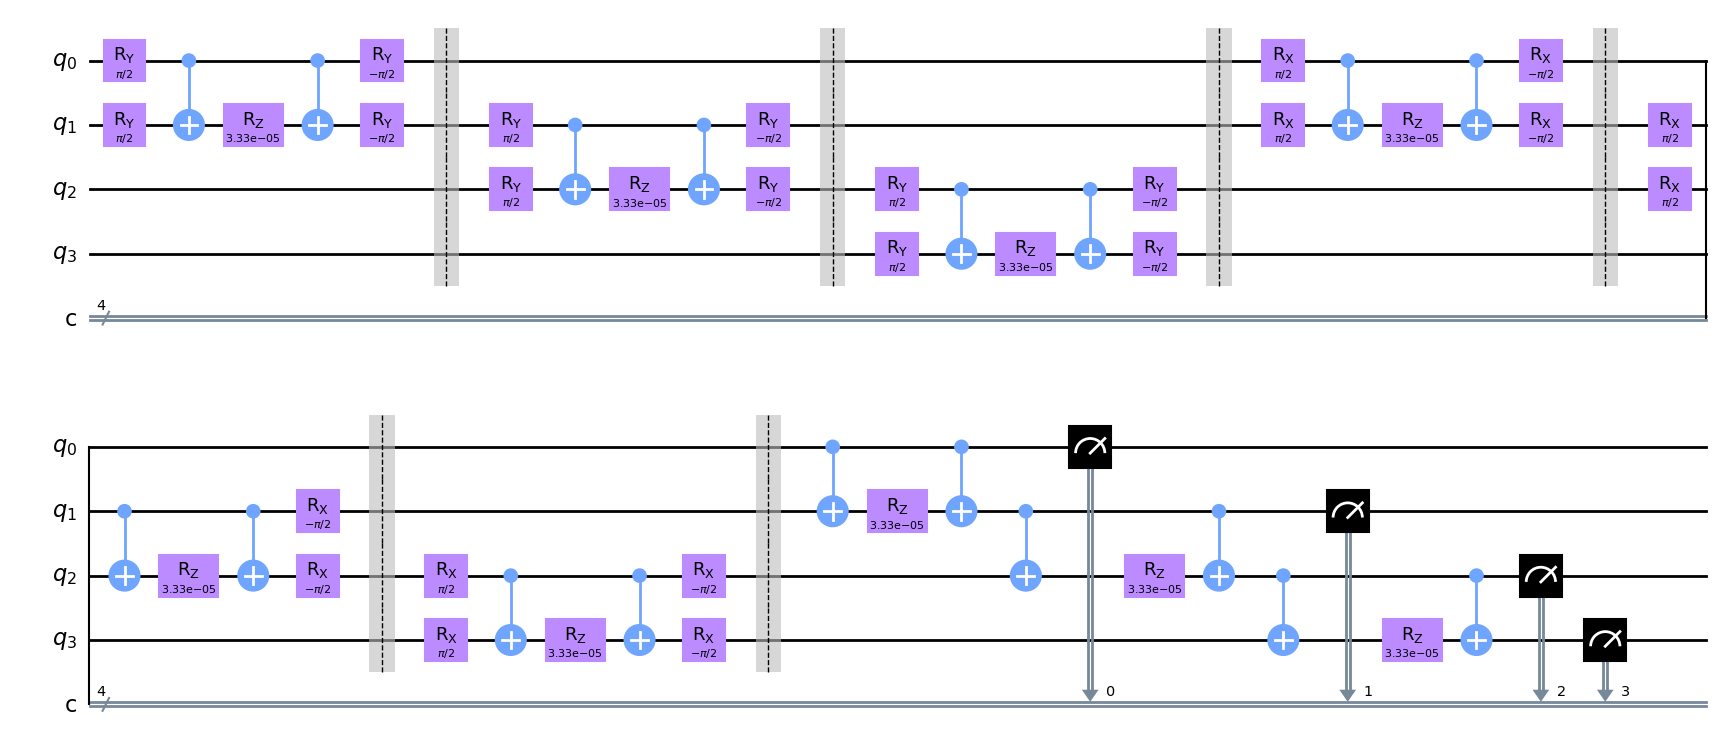

In [21]:
# Draw full circuit

# q = QuantumRegister(2, "q")
# c = ClassicalRegister(2, "c")
# # Define Ising Model Circuit "ic" for simulation
# ic = QuantumCircuit(q,c)

qr = QuantumRegister(N, 'q')
cr = ClassicalRegister(N, 'c')
qc = QuantumCircuit(qr,cr)
dt = 0.05

heisenberg(qc, qr, cr)

qc.draw('mpl')

In [ ]:
# Transpile the quantum circuit to low-level QASM instructions
#from qiskit import transpile
#circ_compiled = transpile(circ, backend)

In [ ]:
# Execute the circuit on the Qasm simulator, repeating 1024 times
#job_sim = backend.run(circ_compiled, shots=1024)

In [ ]:
# Grab the results from the job
#result_sim = job_sim.result()

In [22]:
def digit_sum(n):
    num_str = str(n)
    sum = 0
    for i in range(0, len(num_str)):
        sum += int(num_str[i])
    return sum

In [ ]:
# initial_state = 0.5 *  DensityMatrix.from_label('0').data +  0.5 * DensityMatrix.from_label('1').data
# initial_state = np.kron(initial_state, initial_state)  # Extend this for N qubits appropriately


In [23]:
# SIMULATOR #

shots = 1024
coupling_map = None
mag_sim = []
# Simulation and expected value calculation
sigma_z_values = []
for i in range(200):
    # ic = QuantumCircuit(q,c)
    qr = QuantumRegister(N, 'q')
    cr = ClassicalRegister(N, 'c')
    qc = QuantumCircuit(qr,cr)
    t = 0.00005
    dt=i*t
    
    heisenberg(qc, qr, cr)
    #  Add the measurement here, after the ising function call
    # qc.measure(qr, cr)
    
    
    
    result = execute(qc, backend=backend,
                    coupling_map=coupling_map, shots=shots).result()
    res = result.get_counts(qc)
    
    # result = execute(qc, backend=backend, coupling_map=coupling_map, initial_state=initial_state, shots=shots).result()
    # res = result.get_counts(qc)
    
    
    # Transpile the circuit for the backend
    # tqc = transpile(qc, backend)
    
    # # Execute the transpiled circuit
    # result = execute(tqc, backend=backend, shots=shots).result()
    # res = result.get_counts(tqc)  # Use the transpiled circuit as the argument
    
    print("res = ", res)
    
    r1=list(res.keys())
    
    #print("r1 - keys = ", r1, "len(r1) = ", len(r1))
    
    r2=list(res.values())
    
    #print("r2 - values = ", r2)
    
    print("                          ")
    
# #===============================    
    M=0
    
    for j in range(0,len(r1)):
        
        #print("digit_sum(r1[j] = ", digit_sum(r1[j]))
        #print("r2[j] = ", r2[j])
        #print("                  ")
        
        M = M + (2 - 1*digit_sum(r1[j]))*r2[j]/shots
        
    print("time: ",dt, ";  <sigma_z>: ", M/N)
    print("                  ")
    
    mag_sim.append(M/N)

    # # Calculate expectation value of sigma_z for this step
    # sigma_z = 0
    # for outcome in res:
    #     # Convert the outcome to sigma_z contributions
    #     sigma_z_contribution = sum([1 if bit == '0' else -1 for bit in outcome]) / 2
    #     sigma_z += sigma_z_contribution * res[outcome] / shots
    # sigma_z_values.append(sigma_z)
    # print( "<sigma_z>: ", sigma_z_values)

res =  {'0000': 1024}
                          
time:  0.0 ;  <sigma_z>:  0.5
                  
res =  {'0000': 1024}
                          
time:  5e-05 ;  <sigma_z>:  0.5
                  
res =  {'0000': 1024}
                          
time:  0.0001 ;  <sigma_z>:  0.5
                  
res =  {'0000': 1024}
                          
time:  0.00015000000000000001 ;  <sigma_z>:  0.5
                  
res =  {'0000': 1024}
                          
time:  0.0002 ;  <sigma_z>:  0.5
                  
res =  {'0000': 1024}
                          
time:  0.00025 ;  <sigma_z>:  0.5
                  
res =  {'0000': 1024}
                          
time:  0.00030000000000000003 ;  <sigma_z>:  0.5
                  
res =  {'0000': 1024}
                          
time:  0.00035 ;  <sigma_z>:  0.5
                  
res =  {'0000': 1024}
                          
time:  0.0004 ;  <sigma_z>:  0.5
                  
res =  {'0000': 1024}
                          
time:  0.000

res =  {'0000': 1024}
                          
time:  0.00075 ;  <sigma_z>:  0.5
                  
res =  {'0000': 1024}
                          
time:  0.0008 ;  <sigma_z>:  0.5
                  
res =  {'0000': 1024}
                          
time:  0.0008500000000000001 ;  <sigma_z>:  0.5
                  
res =  {'0000': 1024}
                          
time:  0.0009000000000000001 ;  <sigma_z>:  0.5
                  
res =  {'0000': 1024}
                          
time:  0.00095 ;  <sigma_z>:  0.5
                  
res =  {'0000': 1024}
                          
time:  0.001 ;  <sigma_z>:  0.5
                  
res =  {'0000': 1024}
                          
time:  0.0010500000000000002 ;  <sigma_z>:  0.5
                  
res =  {'0000': 1024}
                          
time:  0.0011 ;  <sigma_z>:  0.5
                  
res =  {'0000': 1024}
                          
time:  0.00115 ;  <sigma_z>:  0.5
                  
res =  {'0000': 1024}
                      

In [ ]:
# Plot histogram
#from qiskit.visualization import plot_histogram
#plot_histogram(counts)

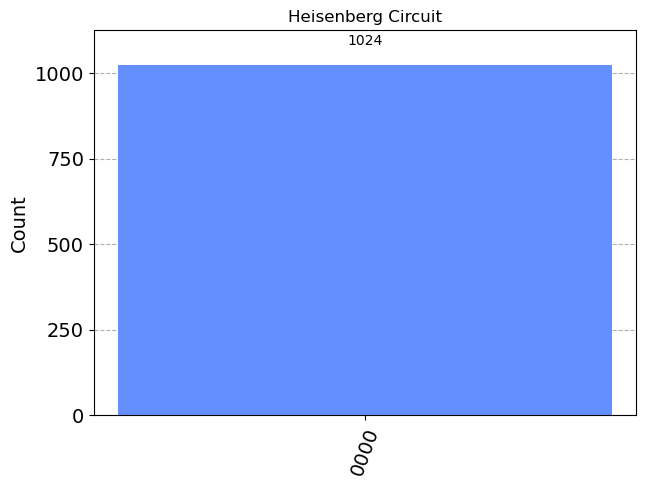

In [25]:
    qr = QuantumRegister(N, 'q')
    cr = ClassicalRegister(N, 'c')
    qc = QuantumCircuit(qr,cr)
    
    # dt=i*0.05
    
    heisenberg(qc, qr, cr)
    #  Add the measurement here, after the ising function call
    qc.measure(qr, cr)
    
    
    
    # result = execute(qc, backend=backend,
    #                 coupling_map=coupling_map, shots=shots).result()
    # res = result.get_counts(qc)

# # result = execute(qc, backend=backend, coupling_map=coupling_map, initial_state=initial_state, shots=shots).result()
# # res = result.get_counts(qc)

result = execute(qc, backend=backend,
                coupling_map=coupling_map, shots=shots).result()
counts = result.get_counts(qc)
plot_histogram(counts, title="Heisenberg Circuit")

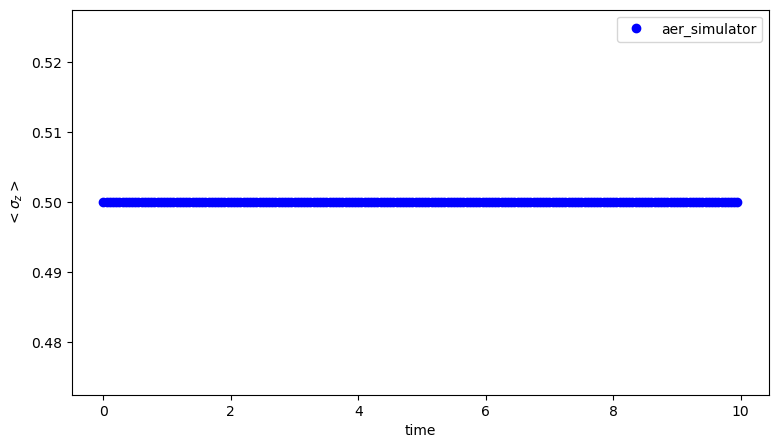

In [26]:
# Plot results

l1=np.arange(0.0,10.0,0.05)
#l1=np.arange(0.0,20.0,0.05)
plt.figure(figsize=(9,5))
# plt.plot(l1, sigma_z_values, 'bo',label='aer_simulator')
#plt.plot(l,vexact(l),'k',label='exact')
plt.plot(l1, mag_sim, 'bo',label='aer_simulator')
#plt.plot(l1, mag_sim, 'bo',label='simulator_mps')
#plt.plot(l1, mag_sim, 'r*',label='ibmq_qasm_simulator')
#plt.xlabel('$\lambda$')
plt.xlabel('time')
plt.ylabel('$<\sigma_{z}>$')
plt.legend()
# plt.title('N=2 heisenberg spin chain')
plt.show()